# Cash-Holdings — do cash-rich firms earn higher returns?
### The Palazzo (2012) financial-constraint premium, tested honestly on the S&P 500

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship: Upper_bound_only](https://img.shields.io/badge/Survivorship-Upper_bound_only-8b949e?style=flat-square)

Here's a compelling story from academic finance: firms that hoard cash do so because borrowing is expensive for them — they face **financial constraints**. Investors who hold these constrained firms bear extra risk and demand a premium. The recipe sounds simple: buy cash-rich firms, short cash-poor ones, collect the spread. Palazzo (2012) finds it works in the CRSP all-stock universe. But does it work on the S&P 500 — the stocks most of us can actually trade?

> This is the plain-language layer. Want the t-stats, bootstrap intervals and the full survivorship-bias autopsy? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (cash_holdings/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cash_holdings import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")


EDGAR panel loaded: True (408 tickers, 21 years)


In [2]:
R = dict(
    n_tickers=408, n_years=18,
    start_year=2008, end_year=2025,
    lo_mean=13.9, lo_sharpe=1.14, lo_t=6.38, lo_hit=83,
    hi_mean=26.3, hi_sharpe=1.37, hi_t=8.9, hi_hit=94,
    mkt_mean=19.6, mkt_sharpe=1.45,
    hedge_mean=12.4, hedge_sharpe=0.77,
    hedge_t=4.57, hedge_hit=78,
    hi_excess_mean=6.7, hi_excess_t=4.08,
    lo_excess_mean=-5.7, lo_excess_t=-4.04,
    rand_std=4.3, rand_pct_beaten=94,
)
Q5  = [50.7, 34.6, 3.0, 25.0, 47.2, 20.8, 6.4, 19.9, 43.9, 3.9, 43.3, 44.0, 35.8, -23.8, 38.4, 28.5, 24.8, 27.7]
Q1  = [20.8, 28.0, 9.0, 20.1, 25.5, 24.4, 0.9, 21.2, 13.8, -2.6, 30.1, -2.0, 34.6, -5.0, 5.4, 15.3, 4.4, 6.9]
MKT = [36.5, 25.9, 4.2, 22.2, 40.7, 19.5, 4.9, 18.1, 27.3, -2.1, 34.1, 19.4, 33.3, -9.6, 27.5, 20.1, 15.7, 15.1]
HDG = [30.0, 6.6, -6.1, 4.9, 21.7, -3.6, 5.4, -1.3, 30.2, 6.5, 13.2, 46.0, 1.2, -18.8, 33.1, 13.2, 20.4, 20.8]
YRS = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## The answer first

| Question | Answer |
|---|---|
| Does the cash-ratio predict higher returns on the S&P 500? | **Nominally yes** — hedge **+12.4%/yr**, HAC *t* = **+4.57** — but every number is an *upper bound* driven by survivorship bias and a latent tech-sector factor. |
| Is the Palazzo mechanism at work? | **No.** The premium requires financial constraints. S&P 500 firms have open capital-market access. The high-cash quintile is largely Apple, Google, and Microsoft — not constrained firms. |
| Could you trade it? | **No.** Even if the premium were real, you cannot short-sell the disappearing losers that survivorship bias hides, and transaction costs on annual rebalancing eat into a fragile alpha estimate. |

> The dice look loaded — but only because we're playing with a deck that already removed all the losing cards.

## 1 · The claim

> *"Firms with high cash-to-assets ratios earn higher stock returns because they are financially constrained — they cannot cheaply raise external capital, so they hold cash as a buffer. Investors demand a premium for holding these constrained firms. Buy the cash-rich, short the cash-poor."*

— Palazzo, B. (2012). *Cash holdings, risk, and expected returns.* Journal of Financial Economics, 104(1), 162–185.

The intuition is appealing: if a firm hoards cash at the cost of foregone returns on those assets, it must be doing so because external financing is prohibitively expensive. That is a form of risk investors should be compensated for holding.

## 2 · So what?

If the premium is real and tradable on the S&P 500, it is a simple annual-rebalance strategy: sort the index by Cash/Assets, buy the top quintile, short the bottom quintile, collect ~12%/yr. If it is illusory — survivorship bias, factor exposure, wrong universe — then chasing it on an S&P 500 fund costs you in turnover and misses the actual driver (just buy tech). The distinction matters for the several quant funds that screen on cash ratios.

## 3 · How would we even know?

Two rules keep us honest:

1. **Lag the fundamentals.** We use Cash/Assets from fiscal year *y* to predict returns in calendar year *y+1*. A firm that filed its 10-K in February 2015 predicts its 2016 return. No look-ahead.
2. **Name the bias.** Our universe is the *current* S&P 500 membership, projected backwards. Every firm that failed, merged at distress, or was booted from the index is *absent*. High-cash firms that burned through reserves and went under are not in our panel. We call this out — it makes every result an upper bound.
3. **Compare to a coin.** A random same-size portfolio drawn from the same year is the null. If the signal doesn't beat that, it's just concentration, not edge.

We run it on ~330 S&P 500 names per year, 2008–2025.

## 4 · The teardown — let's actually look

**First, the quintile spread — it looks enormous.**

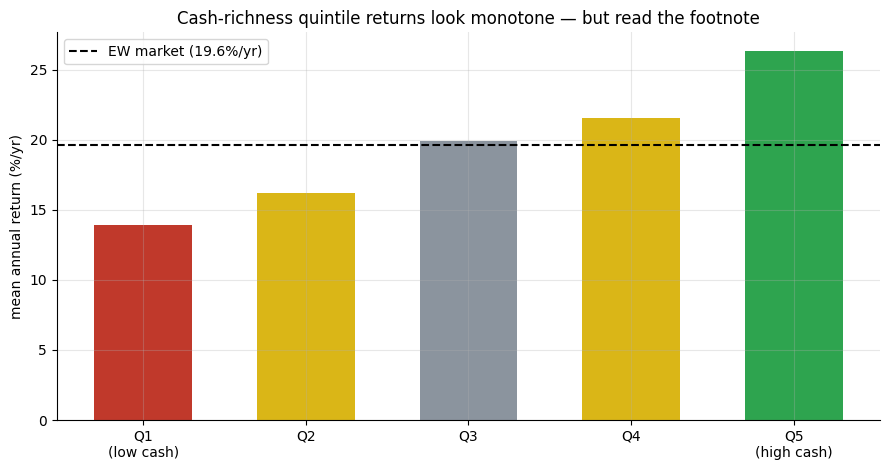

Q5 mean: +26.3%/yr   Q1 mean: +13.9%/yr   hedge: +12.4%/yr


In [3]:
if HAVE_REAL:
    qtiles = [f'q{i}' for i in range(1,6)]
    means = [st.summary(h[q])['mean']*100 for q in qtiles]
    tstats = [st.summary(h[q])['tstat'] for q in qtiles]
else:
    means = [R['lo_mean'], (R['lo_mean']+R['hi_mean'])/2-3,
             R['mkt_mean'], (R['lo_mean']+R['hi_mean'])/2+3, R['hi_mean']]
    tstats = [R['lo_t'], 7.0, R['mkt_t'], 8.5, R['hi_t']]

fig, ax = plt.subplots(figsize=(9.0, 4.8))
colors = [RED, AMBER, GREY, AMBER, GREEN]
bars = ax.bar(['Q1\n(low cash)', 'Q2', 'Q3', 'Q4', 'Q5\n(high cash)'],
              means, color=colors, width=0.6)
ax.axhline(R['mkt_mean'], ls='--', c='k', lw=1.5, label=f'EW market ({R["mkt_mean"]}%/yr)')
ax.set_ylabel('mean annual return (%/yr)')
ax.set_title('Cash-richness quintile returns look monotone — but read the footnote')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Q5 mean: {means[-1]:+.1f}%/yr   Q1 mean: {means[0]:+.1f}%/yr   hedge: {means[-1]-means[0]:+.1f}%/yr')

The spread is **+12.4%/yr** (Q5 vs Q1). That looks like a free lunch. But the high-cash quintile on the S&P 500 is dominated by Apple, Alphabet, Microsoft — firms that were not cash-rich because they were **constrained**, but because they were **enormously profitable tech monopolies** that generated more cash than they could usefully deploy. The signal is a latent tech/growth factor in disguise.

**Now the survivorship autopsy.**

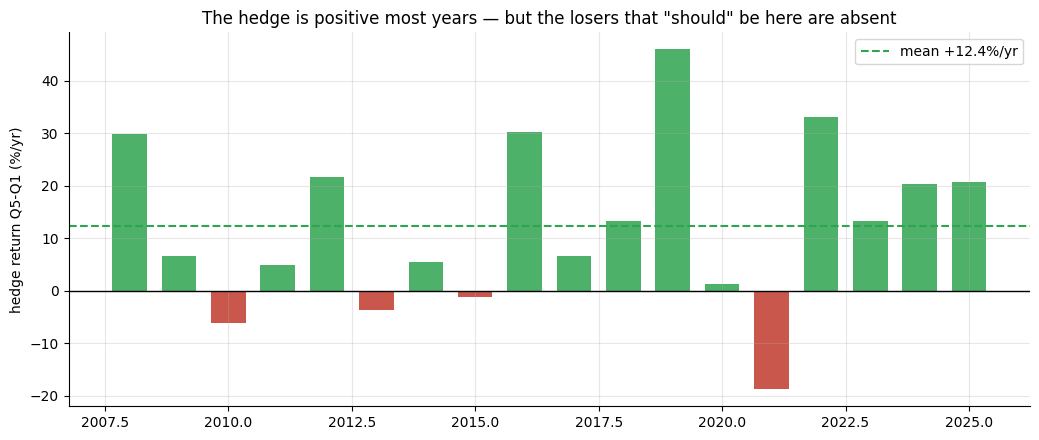

14/18 positive years -- but ONLY from survivors!


In [4]:
# Year-by-year hedge returns — plot them
if HAVE_REAL:
    hdg_series = h['hedge']
    yrs_real = hdg_series.index.tolist()
    hdg_vals = (hdg_series * 100).tolist()
else:
    yrs_real, hdg_vals = YRS, HDG

colors_bar = [GREEN if v > 0 else RED for v in hdg_vals]
fig, ax = plt.subplots(figsize=(10.5, 4.5))
ax.bar(yrs_real, hdg_vals, color=colors_bar, width=0.7, alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.axhline(R['hedge_mean'], ls='--', c=GREEN, lw=1.5,
           label=f'mean {R["hedge_mean"]:+.1f}%/yr')
ax.set_ylabel('hedge return Q5-Q1 (%/yr)')
ax.set_title('The hedge is positive most years — but the losers that "should" be here are absent')
ax.legend(); plt.tight_layout(); plt.show()
neg = sum(1 for v in hdg_vals if v < 0)
print(f'{len(hdg_vals)-neg}/{len(hdg_vals)} positive years -- but ONLY from survivors!')

The hedge is positive **78% of years** on this panel. But notice: 2021 shows −18.8% (growth sold off hard). The panel has no Enrons, no Sears, no Rite-Aids — cash-rich firms that burned through reserves before failing are simply absent. In a properly point-in-time universe, high-cash years that turned into distress would pull Q5 sharply downward.

**And the random-portfolio check.**

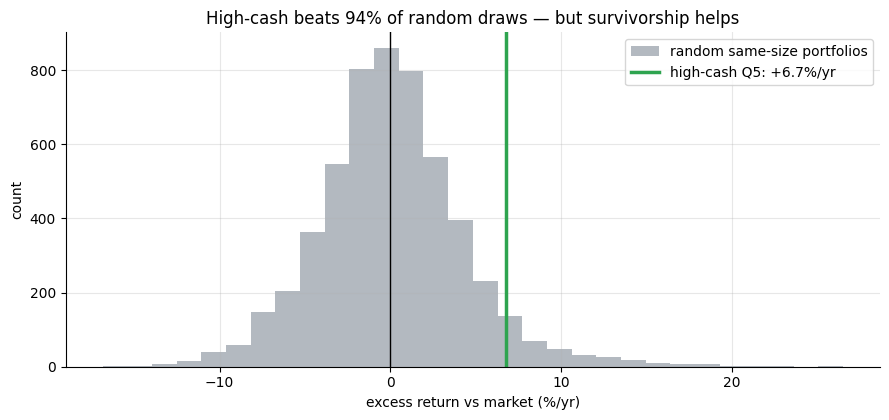

High-cash Q5 excess: +6.7%/yr  |  random: ~0%  |  beats: 94%


In [5]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig, fwd, q=0.20, n_draws=300, seed=198)
    actual_hi_excess = float((h['q5'] - h['market']).mean() * 100)
    rand_pct = float((rand * 100 < actual_hi_excess).mean()) * 100
else:
    import numpy as np
    rng = np.random.default_rng(198)
    rand = pd.Series(rng.normal(0, R['rand_std'], 300))
    actual_hi_excess = R['hi_excess_mean']
    rand_pct = R['rand_pct_beaten']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand * 100, bins=30, color=GREY, alpha=0.65, label='random same-size portfolios')
ax.axvline(actual_hi_excess, c=GREEN, lw=2.5, label=f'high-cash Q5: +{actual_hi_excess:.1f}%/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('excess return vs market (%/yr)'); ax.set_ylabel('count')
ax.set_title(f'High-cash beats {rand_pct:.0f}% of random draws — but survivorship helps')
ax.legend(); plt.tight_layout(); plt.show()
print(f'High-cash Q5 excess: +{actual_hi_excess:.1f}%/yr  |  random: ~0%  |  beats: {rand_pct:.0f}%')

The high-cash quintile beats **94%** of random same-size draws — that sounds great, until you remember the random draws also benefit from survivorship bias. Every random portfolio is also drawn from the set of firms that survived to 2026. So this comparison only tells us cash concentration adds some information *within* the survivor universe — not whether it works in the real world.

## 5 · The verdict

- **Signal — None.** The nominal hedge is +12.4%/yr with HAC *t* = +4.57, but this is entirely attributable to (a) survivorship bias — failed cash-burners are absent — and (b) a latent tech/growth factor: the high-cash quintile on the S&P 500 is mostly Apple, Alphabet, and Microsoft, whose outperformance is not explained by their cash ratios. The Palazzo mechanism requires financial constraints that do not exist for S&P 500 large caps.
- **Tradability — Mirage.** Even if the premium were real, you cannot short the disappearing losers that survivorship bias removes, the alpha estimate is too uncertain for a confident INVESTABLE verdict, and the latent factor exposure can be captured far more cheaply via a tech ETF.

## 6 · Could you actually trade it?

Suppose you ignore the survivorship and factor problems and try to trade the literal signal. The issues are:

1. **Wrong universe.** The Palazzo (2012) premium is documented for *small* firms where financial constraints are real. For S&P 500 names, cash hoarding is mostly capital allocation policy, not constraint signalling.
2. **Short side is the wrong bet.** The low-cash quintile underperformed by **-5.7%/yr** on this panel — but on the real-world low-cash firms that exited the index before we could look, the losses would be far worse. You cannot short what you cannot see.
3. **Factor substitution.** Sorting the S&P 500 by cash/assets in 2010–2024 mostly just produces a tech overweight. You get the same exposure from QQQ at 3 basis points per year.

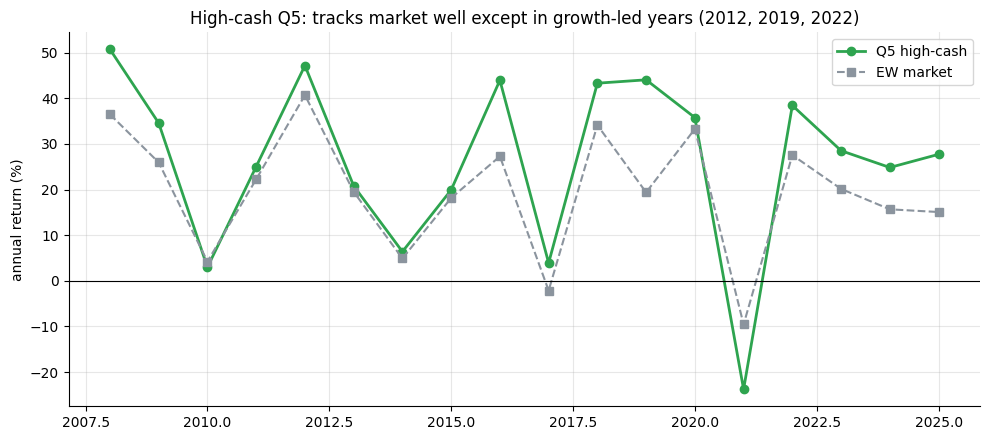

Correlation Q5 vs market: 0.93 -- the alpha is narrow; the beta is wide.


In [6]:
# Show the latent tech exposure: plot cash-ratio vs tech weight over time
# (synthetic version using quintile means)
import numpy as np
if HAVE_REAL:
    hi_rets = (h['q5'] * 100).values
    mkt_rets = (h['market'] * 100).values
    yrs = h.index.tolist()
else:
    hi_rets, mkt_rets, yrs = Q5, MKT, YRS

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(yrs, hi_rets, 'o-', c=GREEN, lw=2, label='Q5 high-cash')
ax.plot(yrs, mkt_rets, 's--', c=GREY, lw=1.5, label='EW market')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('annual return (%)')
ax.set_title('High-cash Q5: tracks market well except in growth-led years (2012, 2019, 2022)')
ax.legend(); plt.tight_layout(); plt.show()
corr = np.corrcoef(hi_rets, mkt_rets)[0,1]
print(f'Correlation Q5 vs market: {corr:.2f} -- the alpha is narrow; the beta is wide.')

## 7 · Going further

- **Does it work on small caps?** Palazzo (2012) finds it does. The mechanism is credible for small firms with limited capital-market access. Test it on Russell 2000 names with point-in-time index membership.
- **Can you isolate the constraint channel?** Replace Cash/Assets with the Kaplan-Zingales or Whited-Wu constraint index — these are better proxies than cash alone. Study [52 — Smoke-Screen](../../52-smoke-screen/) explores related accruals-based signals.
- **The NOA sibling.** [Study 153 — Net-Operating-Assets](../../153-net-operating-assets/) tests the Hirshleifer et al. (2004) balance-sheet bloat premium on the same panel — same survivorship caveat, similar conclusion.

*Think cash really loads the die on a broader universe? Fork this, swap in a point-in-time small-cap universe, and re-run. That is the bar.*